In [1]:
!pip install torch torchvision torch-geometric matplotlib scikit-learn numpy -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 23.1 MB/s eta 0:00:00a 0:00:01


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [3]:
transform = transforms.ToTensor()
train_data = datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_data  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_data,  batch_size=128, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 39.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.10MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.1MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.26MB/s]


In [4]:
LATENT_DIM = 2   

class VAE(nn.Module):
    def __init__(self, latent_dim=2):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(784, 400),
            nn.ReLU()
        )
        self.fc_mu     = nn.Linear(400, latent_dim)
        self.fc_logvar = nn.Linear(400, latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 400),
            nn.ReLU(),
            nn.Linear(400, 784),
            nn.Sigmoid()
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        x = x.view(-1, 784)
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar


def vae_loss(recon_x, x, mu, logvar):
    """Reconstruction loss + KL Divergence"""
    BCE = nn.functional.binary_cross_entropy(recon_x, x.view(-1, 784), reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KLD


vae = VAE(latent_dim=LATENT_DIM).to(device)
optimizer_vae = optim.Adam(vae.parameters(), lr=1e-3)
print(vae)

VAE(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=400, bias=True)
    (1): ReLU()
  )
  (fc_mu): Linear(in_features=400, out_features=2, bias=True)
  (fc_logvar): Linear(in_features=400, out_features=2, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=2, out_features=400, bias=True)
    (1): ReLU()
    (2): Linear(in_features=400, out_features=784, bias=True)
    (3): Sigmoid()
  )
)


Epoch 1/10  Loss: 190.4896
Epoch 2/10  Loss: 168.1590
Epoch 3/10  Loss: 163.7296
Epoch 4/10  Loss: 161.0815
Epoch 5/10  Loss: 159.1695
Epoch 6/10  Loss: 157.8361
Epoch 7/10  Loss: 156.7214
Epoch 8/10  Loss: 155.8606
Epoch 9/10  Loss: 155.1061
Epoch 10/10  Loss: 154.4703


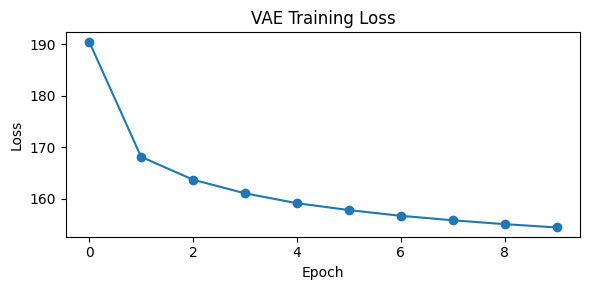

In [5]:
EPOCHS_VAE = 10
vae_losses = []

for epoch in range(1, EPOCHS_VAE + 1):
    vae.train()
    total_loss = 0
    for x, _ in train_loader:
        x = x.to(device)
        optimizer_vae.zero_grad()
        recon, mu, logvar = vae(x)
        loss = vae_loss(recon, x, mu, logvar)
        loss.backward()
        optimizer_vae.step()
        total_loss += loss.item()
    avg = total_loss / len(train_loader.dataset)
    vae_losses.append(avg)
    print(f"Epoch {epoch}/{EPOCHS_VAE}  Loss: {avg:.4f}")

plt.figure(figsize=(6,3))
plt.plot(vae_losses, marker='o')
plt.title('VAE Training Loss'); plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.tight_layout(); plt.show()

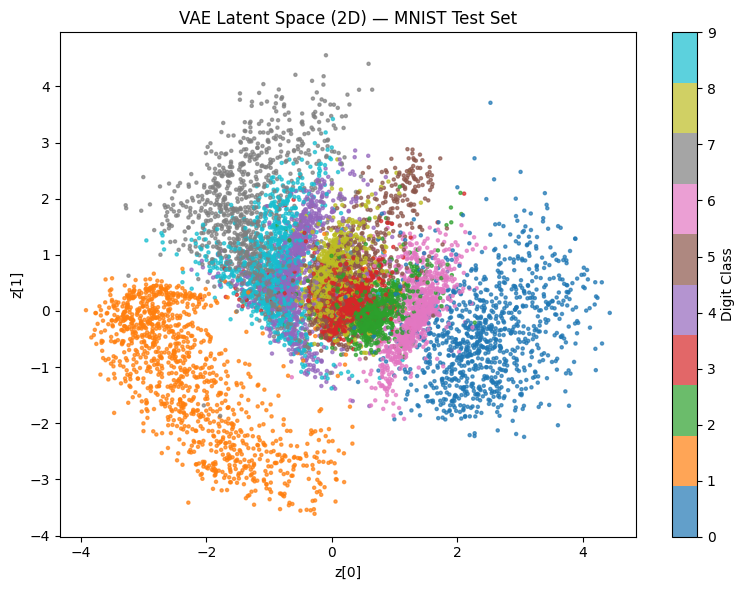

In [6]:
vae.eval()
all_z, all_labels = [], []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        mu, _ = vae.encode(x.view(-1, 784))
        all_z.append(mu.cpu().numpy())
        all_labels.append(y.numpy())

all_z      = np.concatenate(all_z)
all_labels = np.concatenate(all_labels)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(all_z[:, 0], all_z[:, 1],
                      c=all_labels, cmap='tab10', s=5, alpha=0.7)
plt.colorbar(scatter, label='Digit Class')
plt.title('VAE Latent Space (2D) — MNIST Test Set')
plt.xlabel('z[0]'); plt.ylabel('z[1]')
plt.tight_layout(); plt.show()

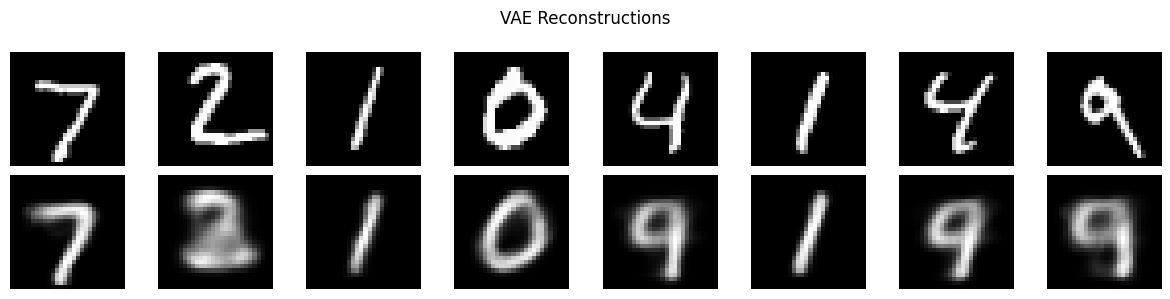

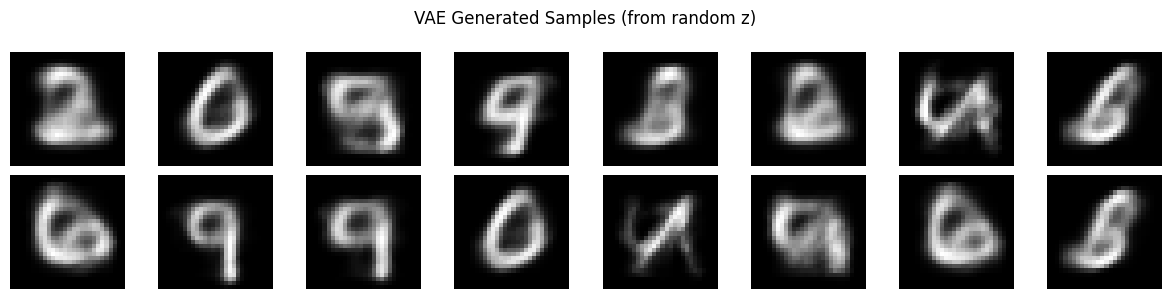

In [7]:
vae.eval()
sample_x, _ = next(iter(test_loader))
sample_x = sample_x[:8].to(device)

with torch.no_grad():
    recon, _, _ = vae(sample_x)

fig, axes = plt.subplots(2, 8, figsize=(12, 3))
for i in range(8):
    axes[0, i].imshow(sample_x[i].cpu().squeeze(), cmap='gray'); axes[0, i].axis('off')
    axes[1, i].imshow(recon[i].cpu().view(28,28),   cmap='gray'); axes[1, i].axis('off')
axes[0, 0].set_ylabel('Original', fontsize=9)
axes[1, 0].set_ylabel('Recon',    fontsize=9)
plt.suptitle('VAE Reconstructions'); plt.tight_layout(); plt.show()

with torch.no_grad():
    z_sample = torch.randn(16, LATENT_DIM).to(device)
    generated = vae.decode(z_sample).cpu().view(-1, 28, 28)

fig, axes = plt.subplots(2, 8, figsize=(12, 3))
for i, ax in enumerate(axes.flat):
    ax.imshow(generated[i], cmap='gray'); ax.axis('off')
plt.suptitle('VAE Generated Samples (from random z)'); plt.tight_layout(); plt.show()

In [8]:
NOISE_DIM = 100

class Generator(nn.Module):
    def __init__(self, noise_dim=100):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(noise_dim, 256), nn.LeakyReLU(0.2), nn.BatchNorm1d(256),
            nn.Linear(256, 512),       nn.LeakyReLU(0.2), nn.BatchNorm1d(512),
            nn.Linear(512, 1024),      nn.LeakyReLU(0.2), nn.BatchNorm1d(1024),
            nn.Linear(1024, 784),      nn.Tanh()
        )
    def forward(self, z):
        return self.net(z).view(-1, 1, 28, 28)


class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 512),  nn.LeakyReLU(0.2), nn.Dropout(0.3),
            nn.Linear(512, 256),  nn.LeakyReLU(0.2), nn.Dropout(0.3),
            nn.Linear(256, 1),    nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x.view(-1, 784))


G = Generator(NOISE_DIM).to(device)
D = Discriminator().to(device)

optimizer_G = optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
optimizer_D = optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))
criterion   = nn.BCELoss()

print("Generator:",     sum(p.numel() for p in G.parameters()), "params")
print("Discriminator:", sum(p.numel() for p in D.parameters()), "params")

Generator: 1489936 params
Discriminator: 533505 params


Epoch  1/20  G: 1.1435  D: 0.8608
Epoch  2/20  G: 0.8294  D: 1.2526
Epoch  3/20  G: 0.8441  D: 1.2596
Epoch  4/20  G: 0.8600  D: 1.2581
Epoch  5/20  G: 0.8437  D: 1.2765
Epoch  6/20  G: 0.8109  D: 1.3033
Epoch  7/20  G: 0.7898  D: 1.3184
Epoch  8/20  G: 0.7698  D: 1.3347
Epoch  9/20  G: 0.7603  D: 1.3400
Epoch 10/20  G: 0.7511  D: 1.3496
Epoch 11/20  G: 0.7479  D: 1.3526
Epoch 12/20  G: 0.7472  D: 1.3543
Epoch 13/20  G: 0.7424  D: 1.3582
Epoch 14/20  G: 0.7418  D: 1.3597
Epoch 15/20  G: 0.7402  D: 1.3601
Epoch 16/20  G: 0.7407  D: 1.3606
Epoch 17/20  G: 0.7405  D: 1.3609
Epoch 18/20  G: 0.7402  D: 1.3620
Epoch 19/20  G: 0.7384  D: 1.3633
Epoch 20/20  G: 0.7356  D: 1.3653


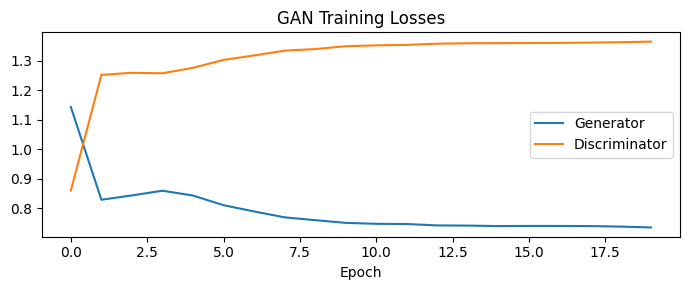

In [9]:
transform_gan = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])   # scale to [-1, 1]
])
gan_data   = datasets.MNIST('./data', train=True, download=True, transform=transform_gan)
gan_loader = DataLoader(gan_data, batch_size=128, shuffle=True)

EPOCHS_GAN = 20
g_losses, d_losses = [], []
fixed_noise = torch.randn(16, NOISE_DIM).to(device)   # for visualization

for epoch in range(1, EPOCHS_GAN + 1):
    G.train(); D.train()
    g_epoch, d_epoch = 0, 0

    for real_imgs, _ in gan_loader:
        real_imgs = real_imgs.to(device)
        batch_sz  = real_imgs.size(0)
        real_lbls = torch.ones(batch_sz, 1).to(device)
        fake_lbls = torch.zeros(batch_sz, 1).to(device)

        # ── Train Discriminator ──
        optimizer_D.zero_grad()
        d_real = criterion(D(real_imgs), real_lbls)
        z      = torch.randn(batch_sz, NOISE_DIM).to(device)
        fake   = G(z).detach()
        d_fake = criterion(D(fake), fake_lbls)
        d_loss = d_real + d_fake
        d_loss.backward(); optimizer_D.step()

        optimizer_G.zero_grad()
        z      = torch.randn(batch_sz, NOISE_DIM).to(device)
        fake   = G(z)
        g_loss = criterion(D(fake), real_lbls)   # fool D
        g_loss.backward(); optimizer_G.step()

        g_epoch += g_loss.item()
        d_epoch += d_loss.item()

    g_losses.append(g_epoch / len(gan_loader))
    d_losses.append(d_epoch / len(gan_loader))
    print(f"Epoch {epoch:2d}/{EPOCHS_GAN}  G: {g_losses[-1]:.4f}  D: {d_losses[-1]:.4f}")

plt.figure(figsize=(7,3))
plt.plot(g_losses, label='Generator'); plt.plot(d_losses, label='Discriminator')
plt.legend(); plt.title('GAN Training Losses'); plt.xlabel('Epoch')
plt.tight_layout(); plt.show()

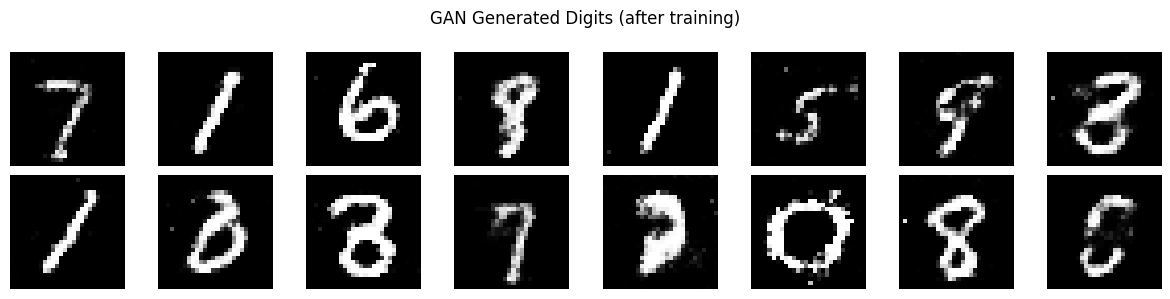

In [10]:
G.eval()
with torch.no_grad():
    fake_imgs = G(fixed_noise).cpu()

fig, axes = plt.subplots(2, 8, figsize=(12, 3))
for i, ax in enumerate(axes.flat):
    ax.imshow(fake_imgs[i].squeeze(), cmap='gray', vmin=-1, vmax=1)
    ax.axis('off')
plt.suptitle('GAN Generated Digits (after training)')
plt.tight_layout(); plt.show()

In [11]:
from torch_geometric.datasets import Planetoid
from torch_geometric.nn import GCNConv
import torch.nn.functional as F
from sklearn.manifold import TSNE

dataset = Planetoid(root='./data/Cora', name='Cora')
data    = dataset[0].to(device)

print(f"Nodes:         {data.num_nodes}")
print(f"Edges:         {data.num_edges}")
print(f"Features:      {data.num_node_features}")
print(f"Classes:       {dataset.num_classes}")
print(f"Train nodes:   {data.train_mask.sum().item()}")
print(f"Val nodes:     {data.val_mask.sum().item()}")
print(f"Test nodes:    {data.test_mask.sum().item()}")

Processing...


Nodes:         2708
Edges:         10556
Features:      1433
Classes:       7
Train nodes:   140
Val nodes:     500
Test nodes:    1000


Done!


In [12]:
class GCN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels,    hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv2(x, edge_index)
        return x   # raw logits (use log_softmax for loss)

    def embed(self, x, edge_index):
        """Return hidden layer embeddings for visualization."""
        x = self.conv1(x, edge_index)
        return F.relu(x)


gcn = GCN(dataset.num_node_features, 64, dataset.num_classes).to(device)
optimizer_gcn = optim.Adam(gcn.parameters(), lr=0.01, weight_decay=5e-4)
print(gcn)

GCN(
  (conv1): GCNConv(1433, 64)
  (conv2): GCNConv(64, 7)
)


In [13]:
def train_gcn():
    gcn.train()
    optimizer_gcn.zero_grad()
    out  = gcn(data.x, data.edge_index)
    loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer_gcn.step()
    return loss.item()

@torch.no_grad()
def test_gcn():
    gcn.eval()
    out  = gcn(data.x, data.edge_index)
    pred = out.argmax(dim=1)
    accs = {}
    for split, mask in [('train', data.train_mask),
                         ('val',   data.val_mask),
                         ('test',  data.test_mask)]:
        accs[split] = (pred[mask] == data.y[mask]).float().mean().item()
    return accs


EPOCHS_GCN = 200
gcn_train_losses, gcn_val_accs = [], []

for epoch in range(1, EPOCHS_GCN + 1):
    loss = train_gcn()
    accs = test_gcn()
    gcn_train_losses.append(loss)
    gcn_val_accs.append(accs['val'])
    if epoch % 20 == 0:
        print(f"Epoch {epoch:3d}  Loss: {loss:.4f}  "
              f"Train: {accs['train']:.4f}  Val: {accs['val']:.4f}  Test: {accs['test']:.4f}")

final = test_gcn()
print(f"\nFinal Test Accuracy: {final['test']*100:.2f}%")

Epoch  20  Loss: 0.0190  Train: 1.0000  Val: 0.7600  Test: 0.7770
Epoch  40  Loss: 0.0151  Train: 1.0000  Val: 0.7620  Test: 0.7960
Epoch  60  Loss: 0.0120  Train: 1.0000  Val: 0.7620  Test: 0.8060
Epoch  80  Loss: 0.0133  Train: 1.0000  Val: 0.7700  Test: 0.8070
Epoch 100  Loss: 0.0127  Train: 1.0000  Val: 0.7720  Test: 0.8060
Epoch 120  Loss: 0.0118  Train: 1.0000  Val: 0.7660  Test: 0.7970
Epoch 140  Loss: 0.0212  Train: 1.0000  Val: 0.7720  Test: 0.8110
Epoch 160  Loss: 0.0144  Train: 1.0000  Val: 0.7540  Test: 0.8030
Epoch 180  Loss: 0.0090  Train: 1.0000  Val: 0.7620  Test: 0.8040
Epoch 200  Loss: 0.0106  Train: 1.0000  Val: 0.7780  Test: 0.8090

Final Test Accuracy: 80.90%


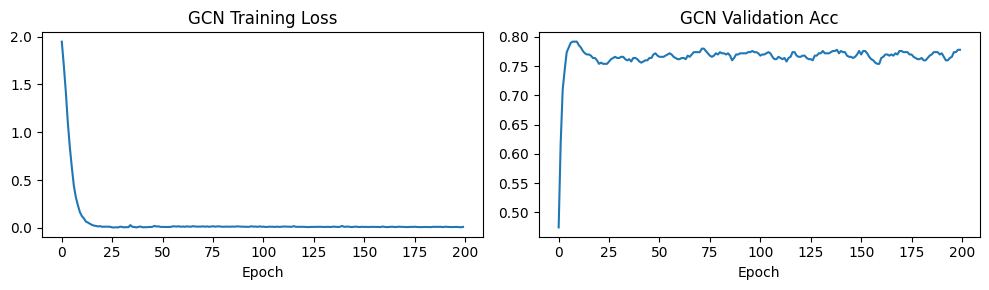

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].plot(gcn_train_losses); axes[0].set_title('GCN Training Loss');   axes[0].set_xlabel('Epoch')
axes[1].plot(gcn_val_accs);     axes[1].set_title('GCN Validation Acc');  axes[1].set_xlabel('Epoch')
plt.tight_layout(); plt.show()

Running t-SNE (this may take ~30s)...


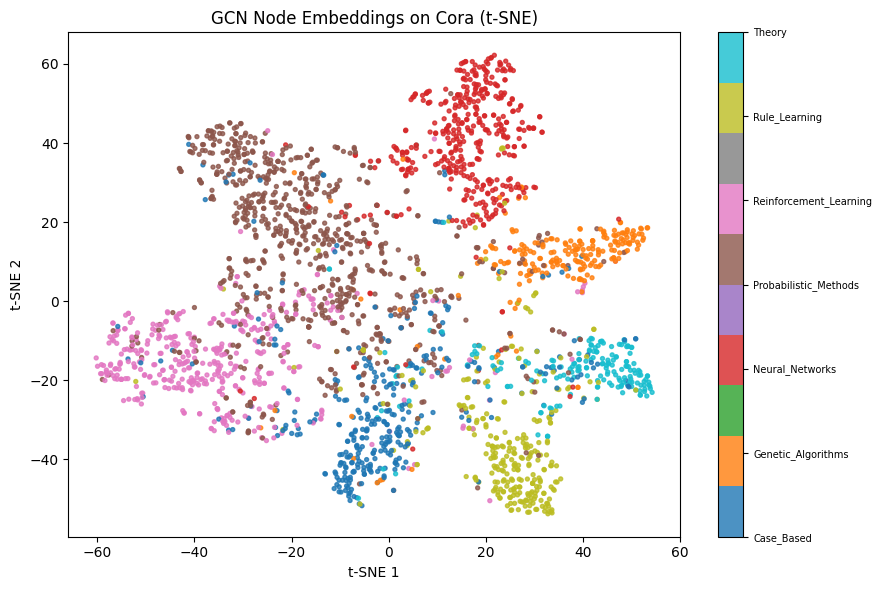

In [15]:
gcn.eval()
with torch.no_grad():
    embeddings = gcn.embed(data.x, data.edge_index).cpu().numpy()
labels = data.y.cpu().numpy()

print("Running t-SNE (this may take ~30s)...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
emb_2d = tsne.fit_transform(embeddings)

class_names = ['Case_Based','Genetic_Algorithms','Neural_Networks',
               'Probabilistic_Methods','Reinforcement_Learning','Rule_Learning','Theory']

plt.figure(figsize=(9, 6))
scatter = plt.scatter(emb_2d[:, 0], emb_2d[:, 1],
                      c=labels, cmap='tab10', s=8, alpha=0.8)
cbar = plt.colorbar(scatter, ticks=range(7))
cbar.ax.set_yticklabels(class_names, fontsize=7)
plt.title('GCN Node Embeddings on Cora (t-SNE)')
plt.xlabel('t-SNE 1'); plt.ylabel('t-SNE 2')
plt.tight_layout(); plt.show()